## Implementacion del enfoque CLR medinate el algortimo greedy

- Autor: Germán Homero Morán Figueroa
- Descripción: En este notebook se realiza la implmentación del algortitmo greedy teneindo en cuenta  2 tareas fundamentales:
    - Entrenamiento del modelo: Fase 1 y Fase 2 que consiste en dividir los grupos en grupos maximizando el valor de R2
    - Validación del modelo con datos no vistos : Ponderación de atributos mediante pesos, en este caso se utiliza la metaherustica SA.

- salida: Del proceso fase 1 y fase 2 se obtienen los respectivos grupos con la calidad requerida y sus respectivos modelos.

In [6]:
# Librerias y dependencias
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.linear_model import LassoCV
from numpy import mean
from numpy import std
from numpy import arange
from numpy import absolute
from pandas import read_csv
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
import sys
import random
import joblib


In [3]:
'''
    Esta clase permite realizar la codificación One Hot especificameente variables categoricas
'''

class OneHotCoding():
    def __init__(self, df, bin_features):
        self.bin_features = bin_features
        self.df = df
    
    # Metodo para realizar la codificacion dummy a las variables categoricas

    def dummyCodification(self):
        cat_features = self.df.select_dtypes(include = ["object", "category"]).columns
        bin_dataset = self.df[self.bin_features].replace({'SI': 1, 'NO': 0})
        categorical_features = [x for x in cat_features if x not in self.bin_features]
        df_cat = pd.get_dummies(self.df[categorical_features],dtype=int)
        self.df.drop(cat_features, axis = 1, inplace = True)
        df_final = pd.concat([self.df,df_cat,bin_dataset ], axis = 1)
        print("Ejeción Terminada")
        return df_final




''' 
Esta clase permite calcular un modelo de regresión Lineal
mediante la libreria de Elasticnet


'''
class LinearRegession():
    def __init__(self, df, alpha, l1_ratio):
        self.df = df
        self.alpha = alpha
        self.l1_ratio = l1_ratio
    

    def CalcularModeloLR(self):
        Y = self.df.RDT_AJUSTADO.values
        X = self.df.drop(["RDT_AJUSTADO","ID_LOTE"], axis=1).values
        modelElasticNet = ElasticNet(alpha=self.alpha, l1_ratio=self.l1_ratio, random_state=123)
        model = modelElasticNet.fit(X,Y)
        r_2 = model.score(X,Y)
        yhat = model.predict(X)
        return [model, r_2, yhat]



'''
  - Esta clase permite contruir el enfoque ClR mediante el algortimo voraz
  - En este caso la clase contiene un metodo que permite ordenar los datos
    respecto al MAE
'''
class CLR():

    def __init__(self, df, yhat):
        self.df = df
        self.yhat = yhat

    
    def calcularMAE(self):
        contador=0
        EPA = 0
        Acumulador = 0
        accepted_average_error= []
        self.df["yhat"]= pd.Series(self.yhat)
        self.df["EA"] = abs(self.df.RDT_AJUSTADO - self.df.yhat)
        self.df_ordely = self.df.sort_values(by=['EA'],ascending=True).reset_index()

        # Calculamos el MAE
        for i in range(len(self.df_ordely)):
            Acumulador = Acumulador + self.df_ordely.loc[i].EA
            EPA = Acumulador/(i+1)
            accepted_average_error.append(EPA)
        
        # Agregamos el promedio al dataset Ordenado.
        self.df_ordely["MAE"] = pd.Series(accepted_average_error)
        #self.df_ordely.to_excel(f"FASE1/DatasetOrdenadoIteraciónesss{contador +1}.xlsx")
        #self.df.to_excel("../Archivos Generados/PipelineResults/DatasetOriginal.xlsx")
        contador=contador+1
        return self.df_ordely
    


''' Función para eliminar registros de la Fase 2'''
def DeleteRecordsGroup(Group, df):
    indexEliminar = list(Group["index"])
    df_new = df[df.index.isin(indexEliminar)== False]
    return df_new


'''Función que permite comparar correlaciones entre 2 Listas'''
def compareCorrelation(CorelacionGruposCalidad, nuevaCorrelation, listaGrupos):
    lista_grupos = listaGrupos
    #print("lista grupos: ",lista_grupos)
    arr =  np.array(CorelacionGruposCalidad) - np.array(nuevaCorrelation)
    position = np.where(arr == np.amin(arr))
    #print("Posision grupo: ",position)
    indexGrupoModificar = position[0][0]
    #print("index: ", indexGrupoModificar)
    lista_grupos.pop(indexGrupoModificar)
    return lista_grupos, indexGrupoModificar


'''Función que permite Normalizar el Dataset'''
def dataframeNormalized(dataset):
    Y = dataset.RDT_AJUSTADO
    X = dataset.drop(["RDT_AJUSTADO"], axis=1)
    # Nombre columnas de X[Variables independientes]
    X_name_columns= X.columns
    scaler = MinMaxScaler()
    X_normalized = scaler.fit_transform(X.values)
    df_X_normalized = pd.DataFrame(X_normalized, columns= X_name_columns)
    df_normalized = pd.concat([df_X_normalized, Y], axis=1)
    print(df_normalized.shape)
    return df_normalized



'''Función para normalizar el dataset completo  - extrayendo los artefactos de [ValMin, valMax, dataRange] 
   para posteriormente normalizar Training and Test '''
def EncoderViewMinable(df):
    new_dataset = df
    norm = MinMaxScaler()
    norm = norm.fit(new_dataset.values[:,:])
    valMin = norm.data_min_
    valMax = norm.data_max_
    dataRange = norm.data_range_
    #df_norm = norm.fit_transform(df.values[:,:-1])

    return [valMin, valMax, dataRange]


'''
Función que permite ejecutar la FASE 1 del algortimo greedy. Es decir se obtienen diferentes
grupos de calidad que cumplan con los criterios definidos, los resgistros que no cumplen se 
etiquetan como huerfanos.
'''

def fase1(dataset,Minimum_records,minimum_correlation, MAE_Allowed,additional_average_error):
    group_acepted = []
    correlation_model =[]
    model_acepted = []
    contador = 0
    while (len(dataset) !=0):
        contador = contador+ 1
        print("Tamaño del dataset: ", dataset.shape)
        modellr, r_2, yhat = LinearRegession(dataset, 0.1, 0.97).CalcularModeloLR()
        print("Ajuste del Modelo dataset Completo: ", r_2)
        DatasetOrdely = CLR(dataset,yhat).calcularMAE()

        try:
            group = DatasetOrdely.loc[DatasetOrdely.MAE < MAE_Allowed]
        except:
             print(f"No se cumple con el criterio de selección, verificar variable MAE_ALLOWED: {MAE_Allowed}")
             break

        print(f"Longitud de grupo {contador}: ", len(group))
        if (len(group) >= Minimum_records):
                print("El grupo cumple minimo de registros")
                group = group.drop(["yhat","EA","MAE"], axis=1)
                dataset = dataset .drop(["yhat","EA"], axis=1)
                group_model, r2_group_mode, yhat_group = LinearRegession(group,0.1,0.97).CalcularModeloLR()
                print(f"R2 del grupo {contador}: ",r2_group_mode)
                if(r2_group_mode >= minimum_correlation):
                    dataset = DeleteRecordsGroup(group, dataset)
                    group = group.drop(['index'], axis=1)
                    group_acepted.append(group)
                    model_acepted.append(group_model)
                    correlation_model.append(r2_group_mode)
                    group.to_excel(f"Resultados/FASE1/GrupoN_{contador}.xlsx")
                    MAE_Allowed = MAE_Allowed + additional_average_error
                else:
                    print("No cumple con la condición de  la correlacion")
                    Orphans = dataset
                    Orphans = Orphans.drop(["yhat", "EA"],axis=1).reset_index(drop=True)
                    print("Logitud Huerfanos: ", Orphans.shape)
                    break  
        else:

            Orphans = dataset
            Orphans = Orphans.drop(["yhat", "EA"],axis=1).reset_index(drop=True)
            print("Logitud Huerfanos: ", Orphans.shape)
            Orphans.to_excel("Resultados/FASE1/HuerfanosN.xlsx")
            break
    
    return [group_acepted, model_acepted, correlation_model, Orphans]



'''
Función que permite ejecutar la Fase 2 del algortimo greedy. En este caso se recorre cada elemento de 
los registros huerfanos y se determina el mejor grupo en base a la variación del coeficiente de 
correlación.
'''

def fase2(group_acepted, correlation_model, Orphans):
    quality_groups = group_acepted.copy()
    correlation_quality_groups = correlation_model.copy()
    new_correlation = []

    group_list = list(range(len(quality_groups)))
    for register in range(len(Orphans)):
        for group in range(len(quality_groups)):
            quality_groups[group] = pd.concat([Orphans.loc[[0]], quality_groups[group]],ignore_index=True)        
            new_model, new_r2, new_yhat = LinearRegession(quality_groups[group],0.1, 0.97).CalcularModeloLR()
            new_correlation.append(new_r2)

        # Compración de las correlaciones
        list_groups_remove, index = compareCorrelation(correlation_quality_groups, new_correlation, group_list)
        correlation_quality_groups[index] = new_correlation[index]
        new_correlation = []
        group_list = list(range(len(quality_groups)))

        # Eliminacion de Regristro en los demas grupos
        for i in list_groups_remove:
            quality_groups[i].drop([0],axis=0, inplace=True)

        Orphans.drop([0],axis=0, inplace=True)
        Orphans = Orphans.reset_index(drop=True)

    return [quality_groups,correlation_quality_groups, Orphans]






'''
Función que permite contruir un unico dataframe con los respectivos grupos de calidad
obtenidos en la FASE 1 y Fase 2
'''
def BuildGroupsQuality(definitive_groups):
    for i in range(len(definitive_groups)):
        definitive_groups[i]["Grupo"]= (i)

    df = pd.concat(definitive_groups, ignore_index=True)
    df = df.drop(["ID_LOTE"], axis=1)
    return df



'''
Funcion para generar el vector de pesos aleatorio.
Entradas:
    w: Vector de pesos w [0,1], igual al numero de caracteristicas normalizadas.
'''
def GenerateWeightVector(size):
    w = np.random.uniform(low=0, high=1, size=(size))
    sum = w.sum()
    w = w / sum

    return w






# Dependiendo del vector de pesos me extrae el acuracy - F1 score

# df: Datasaset distancia que incluye los atributos con los grupos
def qualityFunction(df_norm, wi,df, lista_modelos, limites_15):
    #print("longitud df_norm: ",len(df_norm))
    #print("Longitud wi: ", len(wi))
    y_pred = []
    for i in range(len(df_norm)):
        vrf = df_norm[i] 
        minDep = sys.float_info.max
        posMinDep = 0
        for j in range(len(df_norm)):
            if i != j:
                ri = wi* np.power((df_norm[j] - vrf), 2)
                dE = np.sum(ri)
                if dE < minDep:
                    posMinDep=j
                    minDep = dE
        print(posMinDep)
        modelo = df.values[posMinDep][-1]
        print("Modelo: ", modelo)
        # caculamos la predicción de c/d registro con el modelo seleccionado
        y_pred = lista_modelos[modelo].predict(df.values[:,:-1][i].reshape(1,-1))[0]
        
        if (y_pred >= limites_15.values[i][2]) & (y_pred <= limites_15.values[i][2]):
            contador = contador + 1
        
    qs = contador/len(df_norm)
    print("Calidad: ", qs)
    return qs



'''
Función para generar la memoria Armonica
Entradas:
    MAC: Tamaño de la  Memoria Armonica
    wi: Vector de Pesos.
    nc: Numero de ceros (Selección de atributos)
'''

def GenerateArmonyMemory(df_norm, MAC,df,lista_modelos, limites_15):
    Lw = []
    for i in range (MAC):
        wi = GenerateWeightVector(174)
        Qs = qualityFunction(df_norm, wi,df,lista_modelos, limites_15)
        wiq = np.append(wi, Qs)
        Lw.append(wiq)

    
    Lw.sort(key=lambda x: x[-1], reverse=True)
    return Lw



def ImprovisationGBHS(PAR, hmn, nc,dataset_normalizado , lmp, HMRC,df,lista_modelos, limites_15):

    df_norm = dataset_normalizado

    # Se genera la memoria Armonica - diferentes tamaños
    np.random.seed(123)
    MA = GenerateArmonyMemory(df_norm,hmn,df,lista_modelos, limites_15)
    P=len(MA[0]) 
    
    
    curvaFitnes = []
    vectorIteration= []
    for i in range (lmp):
        pesosAleatorios = np.random.rand(P-1)
        for j in range(P-1):
            Aleatorio1 = random.random() 
            if (Aleatorio1 < HMRC):
                pma = random.randint(0, hmn-1)
                pesosAleatorios[j]= MA[pma][j]

                Aleatorio2 = random.random()
                if Aleatorio2 < PAR:
                    pesosAleatorios[j] = MA[0][j]
            
            else:
                Aleatorio3 = random.random()
                if Aleatorio3 < nc/P:
                    Aleatorio4 = 0
                else:
                    Aleatorio4 = Aleatorio3/(P-nc)
                
                pesosAleatorios[j] = Aleatorio4
        

        # Normalización de los pesos
        wf = GenerateWeightVector(pesosAleatorios, 0)
        fitnes = qualityFunction(df_norm, wf,df)



        # Remplazo
        if MA[hmn -1][P-1] < fitnes:
            new_register = np.append(wf, fitnes)
            MA[hmn-1] = new_register
            #print("------------------------------------")
            MA.sort(key=lambda x: x[-1], reverse=True)
        

        
        curvaFitnes.append(MA[0][P-1])
        vectorIteration.append(MA[0])
        

    
    
    print("Valor de la curva en la ultima poisción: ",curvaFitnes[-1])
    '''
    dicc = {"vector":vectorIteration,
                "Fitnes": curvaFitnes}
    

    df_new = pd.DataFrame(data=dicc)
    df_new.to_csv(f"ResultadosImprovisacion/GBHS.csv")
    dicc = dict()
    '''
    return [curvaFitnes[-1], vectorIteration[-1]]


'''
Funcion para Normalizar la Vista minable a exepción de la etiqueta (Variable Objetivo)
en este caso se utilizan los artefactos [valMin, valMax, dataRange]
- df: es la matriz df.values [] , no incluye la etiqueta del grupo

'''
def NormalizeViewMinable(df,valMin, dataRange):
    dataset_normalizado = np.empty((df.shape[0], df.shape[1]))
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            dataset_normalizado[i][j]= (df[i][j] - valMin[j])/dataRange[j]

    return dataset_normalizado



'''
Función para predecir (y_pred)  con el conjunto de test
Entradas:
         - dataset_test_norm: dataset del conjunto de testeo normalizado
         - df_norm: dataset de entrenamiento normalizado
         - vector_pesos_optimización: Vector de pesos obtenido mediante la optimización con SA
         - dataset_final_join: dataset de entrenamiento , que incluye la etiqueta del grupo asignado
         - list_final_models: Lista definitiva de modelos obtenidos en FASE 1 y FASE 2
         - datset_validation: Dataset de validación

Salida:
        - y_predict_test: Rendimiento predicho con el conjunto de test
        - lista_asignacion de grupos: Asignación Final de Grupos conjunto de test

'''
def predictionTest(dataset_test_norm, df_norm, vector_pesos_optmizacion, final_datset_join, list_final_models,dataset_validation):
    df_groups_finally = df_norm.copy()
    minDep = sys.float_info.max
    lista_asignacion_grupos = []
    print("Longitud dataset norm: ",dataset_test_norm.shape[0])
    print("Vista minable : ",df_groups_finally.shape[0])
    posMinDep = 0
    y_pred_test = []
    for z in range(int(dataset_test_norm.shape[0])):
        for k in range(int(df_groups_finally.shape[0])):
            ri = vector_pesos_optmizacion * np.power((dataset_test_norm[z]- df_groups_finally[k]),2) 
            dE = np.sum(ri)
            if dE < minDep:
                posMinDep = k
                minDep=dE
        
        #print("zz, " , z)
        grupoSelected = int(final_datset_join.values[posMinDep][-1])
        lista_asignacion_grupos.append(grupoSelected)   
        psi_predicho = list_final_models[grupoSelected].predict(dataset_validation.values[z].reshape(1,-1))
        y_pred_test.append(psi_predicho[0])

    return [y_pred_test,lista_asignacion_grupos]



'''Función para calcular las metricas de regresión'''
def metricasModelosRegresion(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    metrics_df = pd.DataFrame({
        'Métrica': ['MSE', 'RMSE', 'MAE', 'R²'],
        'Valor': [mse, rmse, mae, r2]
    })
    return r2, metrics_df




### PARTE 1: Entrenamiento del modelo mediante el algortimo greedy
- Esta parte incluye 2 tareas fundamentales: FASE 1 y FASE 2 , permitiendo obtener grupos con buena calidad segun los prametros de 
entrada definidos por el algortimo.
- Los parametros de entrada del algortimo son:
    - Minimo numero de registros.
    - Minima corralción aceptada.
    - Minimo MAE permitido
    - Error Promedio Adicional
    - Contador
    - Grupos definitivos
      

In [4]:
# Variables Globales
# ==============================================================================
Minimum_records = 64
minimum_correlation= 0.88
MAE_Allowed = 143                                                         #MAE
additional_average_error = 98
contador = 0
definitive_groups = []

#1. Lectura del Dataset Principal
# ==============================================================================

#df = pd.read_excel("../Data/Gold/DatasetFinal.xlsx")
df = pd.read_csv("../../../Data/Gold/DatasetFinalFP.csv")
#print(df.head())
# Ornial variables list
bin_features =['SEM_TRATADAS','DRENAJE','ALMACENAMIENTO_FINCA','CAP_ENDURE_RASTA','MOTEADOS_RASTA','MOTEADOS_MAS70cm._RASTA',
               'OBSERVA_EROSION_RASTA','OBSERVA_MOHO_RASTA','OBSERVA_RAICES_VIVAS_RASTA','OBSERVA_HOJARASCA_MO_RASTA',
                'SUELO_NEGRO_BLANDO_RASTA','CUCHILLO_PRIMER_HTE_RASTA','CERCA_RIOS_QUEBRADAS_RASTA',
               ]


#2. Codificación de variables categoricas - Dummy
# ============================================================
dataset = OneHotCoding(df,bin_features).dummyCodification()
print("Dimension dataset Original: ", dataset.shape)

dataset_original = dataset.copy()
dataset_vindep = dataset.copy()
dataset_vindep= dataset_vindep.drop(["RDT_AJUSTADO","ID_LOTE"],axis=1)



#2. Encoders [Min, Max, data Range] para aplicar data Normalization
# =================================================================
'''
    Entradas: dataset: vista minable de caracteristicas indepenedientes, exepto la V objetivo
'''
valMin, valMax, dataRange = EncoderViewMinable(dataset_vindep)
print("Longitudes : ", len(valMin), len(valMax), len(dataRange))
# Guardamos los encoders apra posteriores usos
np.savetxt('Resultados/FASE2/Encoder_ValMin.txt', valMin)
np.savetxt('Resultados/FASE2/Encoder_dataRange.txt', dataRange)


#3. División de datset Training and Test
# ============================================================
dataset_train, dataset_test = train_test_split(dataset, test_size = 0.1, random_state=92)
print("Longitud Dataset Entrenamiento:",  dataset_train.shape)
dataset_training = dataset_train.copy()


# 4. Construcción de grupos de CalidaD FASE 1
# ============================================================
group_acepted, model_acepted, correlation_model, Orphans = fase1(dataset_training, Minimum_records,minimum_correlation, MAE_Allowed,additional_average_error)
print("---------------- FASE 1---------------------")
print("Correlaciones Iniciales: ", correlation_model)
#print(f"Grupo 1 {len(group_acepted[0])}, Grupo 2: {len(group_acepted[1])}, Grupo 3: {len(group_acepted[2])}")
print("Huerfanos: ", Orphans.shape)


# 5. Construccción de grupos definitivos 
# ============================================================

if len(group_acepted) > 1:
    if len(Orphans) == 0:
        definitive_groups = group_acepted
    
    else:
        # Fase 2, incluir los huerfanos
        print("FASE 2")
        quality_groups, correlation_quality_groups, orphans = fase2(group_acepted,correlation_model, Orphans)
        print("------------------ FASE 2 -------------------")
        print("Correlaciones Finales: ", correlation_quality_groups)
        #print(f"Grupo 1 {len(quality_groups[0])}, Grupo 2: {len(quality_groups[1])}, Grupo 3: {len(quality_groups[2])}")
        print("Huerfanos: ", orphans.shape)
        # Guardamos los grupos Finales
        for c, g in enumerate (quality_groups):
            print(f"Longitud Grupo {c} :  {len(quality_groups[c])} ")
            g.to_excel(f"Resultados/FASE2/grupo_N{c}.xlsx")
   
        
        for c, value in enumerate (correlation_quality_groups):
            if value < 0.88:
                dataset_group = quality_groups[c]
                # Se aplica el mismo proceso que la fase 1
                group_acepted2, model_acepted2, correlation_model2, Orphans2 = fase1(dataset_group ,Minimum_records,minimum_correlation, MAE_Allowed,additional_average_error)
            else:
                definitive_groups.append(quality_groups[c])

 
        
else:
    definitive_groups = Orphans


print("Grupos Definitivos: ", len(definitive_groups))

# Modelos Finales
# ======================================================
list_final_models = []
for i in range(len(definitive_groups)):
    model_final, r2_final, yhat_final = LinearRegession(definitive_groups[i],0.1, 0.97).CalcularModeloLR()
    print("R2: ", r2_final)
    list_final_models.append(model_final)
    


grupos_finales = definitive_groups.copy()


Ejeción Terminada
Dimension dataset Original:  (799, 176)
Longitudes :  174 174 174
Longitud Dataset Entrenamiento: (719, 176)
Tamaño del dataset:  (719, 176)


C:\Users\German\AppData\Roaming\Python\Python38\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.202e+07, tolerance: 1.352e+05
  model = cd_fast.enet_coordinate_descent(


Ajuste del Modelo dataset Completo:  0.7353483834467243
Longitud de grupo 1:  82
El grupo cumple minimo de registros


C:\Users\German\AppData\Roaming\Python\Python38\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.014e+06, tolerance: 8.108e+03
  model = cd_fast.enet_coordinate_descent(


R2 del grupo 1:  0.9836604206704305
Tamaño del dataset:  (637, 176)
Ajuste del Modelo dataset Completo:  0.7579266531777857


...

C:\Users\German\AppData\Roaming\Python\Python38\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.321e+06, tolerance: 9.059e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\German\AppData\Roaming\Python\Python38\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.330e+06, tolerance: 9.129e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\German\AppData\Roaming\Python\Python38\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider in

------------------ FASE 2 -------------------
Correlaciones Finales:  [0.9725819476985545, 0.974715542761889, 0.9630098339827989, 0.970720156046838]
Huerfanos:  (0, 176)
Longitud Grupo 0 :  161 
Longitud Grupo 1 :  195 
Longitud Grupo 2 :  204 
Longitud Grupo 3 :  159 
Grupos Definitivos:  4
R2:  0.9725819476985545
R2:  0.974715542761889
R2:  0.9630098339827989


C:\Users\German\AppData\Roaming\Python\Python38\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.181e+06, tolerance: 3.009e+04
  model = cd_fast.enet_coordinate_descent(
C:\Users\German\AppData\Roaming\Python\Python38\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.698e+06, tolerance: 3.060e+04
  model = cd_fast.enet_coordinate_descent(
C:\Users\German\AppData\Roaming\Python\Python38\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider in

R2:  0.970720156046838


C:\Users\German\AppData\Roaming\Python\Python38\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.115e+06, tolerance: 3.397e+04
  model = cd_fast.enet_coordinate_descent(


In [10]:
definitive_groups[0]

,ID_LOTE,DIAS_EN_EMERGER,DIAS_EN_EMERGER_A_FLORECER,DIAS_EN_FLORECER_A_COSECHAR,POBLACION_20DIAS_AJT,ALTURA_LOT,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,...,CAP_ENDURE_RASTA,MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_RAICES_VIVAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA
1,4222,6,48,79,70000,17,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
2,4254,5,49,81,59700,18,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,3643,5,46,84,65000,9,0,0,0,0,...,0,1,0,0,0,1,0,0,1,1
4,3947,4,49,90,60000,7,1,0,0,0,...,0,0,0,0,0,1,0,0,1,1
5,2275,6,47,84,55000,8,0,0,0,0,...,1,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,2488,5,45,81,72000,10,0,0,0,0,...,1,0,0,0,0,1,1,0,1,1
158,2900,4,47,80,62000,9,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
159,2693,6,53,84,60000,10,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
160,3937,5,47,90,65000,6,0,0,0,0,...,1,1,0,0,0,1,0,0,0,1


In [12]:

# Una vez obtenidos los modelos definitivos se guardan en formato (.pkl) para posteriores usos
# =====================================================================================================
print("Grupos Definitivos: ", len(definitive_groups))

# Modelos Finales
list_final_models = []
for i in range(len(definitive_groups)):
    model_final, r2_final, yhat_final = LinearRegession(definitive_groups[i],0.1, 0.97).CalcularModeloLR()
    print("R2: ", r2_final)
    list_final_models.append(model_final)
    # Gurdamos los modelos en formato .pkl
    joblib.dump(model_final, f'Resultados/FASE2/modelo_{i}.pkl')
    

grupos_finales = definitive_groups.copy()



Grupos Definitivos:  4
R2:  0.9725819476985545
R2:  0.974715542761889


C:\Users\German\AppData\Roaming\Python\Python38\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.181e+06, tolerance: 3.009e+04
  model = cd_fast.enet_coordinate_descent(
C:\Users\German\AppData\Roaming\Python\Python38\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.698e+06, tolerance: 3.060e+04
  model = cd_fast.enet_coordinate_descent(


R2:  0.9630098339827989
R2:  0.970720156046838


C:\Users\German\AppData\Roaming\Python\Python38\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.789e+06, tolerance: 4.039e+04
  model = cd_fast.enet_coordinate_descent(
C:\Users\German\AppData\Roaming\Python\Python38\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.115e+06, tolerance: 3.397e+04
  model = cd_fast.enet_coordinate_descent(


In [40]:
list_final_models

[ElasticNet(alpha=0.1, l1_ratio=0.97, random_state=123),
 ElasticNet(alpha=0.1, l1_ratio=0.97, random_state=123),
 ElasticNet(alpha=0.1, l1_ratio=0.97, random_state=123)]

In [19]:
# Construimos datset de Trainign para etapa de clasificación
# ============================================================
final_datset_join = BuildGroupsQuality(grupos_finales)
print(final_datset_join.shape)

# Eliminamos la variable objetivo (RDT_AJUSTADO) para clasificación se tienen una nueva variable objetivo (Grupo)
# ===============================================================================================================
dataset_ditancia = final_datset_join.drop(["RDT_AJUSTADO"], axis=1)
dataset_ditancia


# Agregamos los limites de las predicciones Reales
# Limite superior [ Y_REAL + 15%]
# Limite Inferior [Y_REAL -15%]
# El limite puede cambiar , si cambia el limite la calidad de la función de aptitud cambia considerablmente.
# ============================================================================================================
Limite = 0.15
df_limite = final_datset_join.copy()
df_limite["RDT_mas15"] = df_limite.RDT_AJUSTADO*Limite + df_limite.RDT_AJUSTADO
df_limite["RDT_menos15"] = df_limite.RDT_AJUSTADO - df_limite.RDT_AJUSTADO*Limite
limites_15 = df_limite[["RDT_AJUSTADO","RDT_mas15","RDT_menos15"]]

# Normalizamos el dataframe de entranmeinto [No icluye RD_AJUSTADO , GRUPO]
# Se normaliza para encontrar el registro mas similar dentro de Training.
# =========================================================================

df_norm = NormalizeViewMinable(dataset_ditancia.values[:,:-1],valMin, dataRange)
print("Longitud del datframe Normalizado: ", df_norm.shape)


(719, 176)
Longitud del datframe Normalizado:  (719, 174)


In [14]:
''' 
Definición Original de la Función de Aptitud 
- Descripción: En este caso se busca obtener un vector de pesos, de tal forma que la predicción 
  de los valores predichoss (y_pred)  segun los modelos obtenidos  caiegan dentro de los limites
  establecidos
  
- Entradas: df_norm: Dataset de entrenamiento normalizdo
                    wi: vector de pesos normalizado generado aleatoriamente
                    df: Datfame original con grupos asignados despues de FASE1 y FASE2
                    lista_modelos: Lista de modelos de ML obtenidos en fase 1 y Fase 2
                    limites_15: Limites de tolerancia del valor real que define el enfoque CLR.
- Salida: qs: se defini como la cantidad de registros que caen dentro de  algunos de los limites (Limites_15) 
              obtenidos con los modelos de machine Learning
'''
def qualityFunction(df_norm, wi,df, lista_modelos, limites_15):
    y_predicho = []
    contador = 0
    for i in range(len(df_norm)):
        vrf = df_norm[i] 
        minDep = sys.float_info.max
        posMinDep = 0
        for j in range(len(df_norm)):
            if i != j:
                ri = wi* np.power((df_norm[j] - vrf), 2)
                dE = np.sum(ri)
                if dE < minDep:
                    posMinDep=j
                    minDep = dE
        #print(posMinDep)
        modelo = df.values[posMinDep][-1]
        # caculamos la predicción de c/d registro con el modelo seleccionado
        y_pred = lista_modelos[int(modelo)].predict(df.values[:,:-1][i].reshape(1,-1))[0]
        if (y_pred >= limites_15.values[i][2]) & (y_pred <= limites_15.values[i][1]):
            contador = contador + 1
        
    qs = contador/len(df_norm)
    return qs


'''
Esta clase define la función de aptitue, internamente se define 
el metodo evaluate, que el mismo definido por la función quality_function

'''
class function_aptitud:
   @staticmethod
   def evaluate(df_norm, wi,df, lista_modelos, limites_15):
      y_predicho = []
      contador = 0
      for i in range(len(df_norm)):
          vrf = df_norm[i] 
          minDep = sys.float_info.max
          posMinDep = 0
          for j in range(len(df_norm)):
              if i != j:
                  ri = wi* np.power((df_norm[j] - vrf), 2)
                  dE = np.sum(ri)
                  if dE < minDep:
                      posMinDep=j
                      minDep = dE
          #print(posMinDep)
          modelo = df.values[posMinDep][-1]
          #print("Modelo: ", int(modelo))
          y_pred = lista_modelos[int(modelo)].predict(df.values[:,:-1][i].reshape(1,-1))[0]
          if (y_pred >= limites_15.values[i][2]) & (y_pred <= limites_15.values[i][1]):
              contador = contador + 1

          
      qs = contador/len(df_norm)

      return qs

    

''' 
    Esa clase define la construcción del vector solución
    Se realiza la inicialización y la modificación o twick que debe realizarse
    a cada elmento en cada iteración. 
'''
class solution:

    def __init__(self, d: int, f, df_norm,df, lista_modelos, limites_15):
        self.size = d
        self.cells = np.zeros(self.size, float)
        self.fitness = 0.0
        self.function = f
        self.df_norm = df_norm
        self.df = df
        self.lista_modelos = lista_modelos
        self.limites_15 = limites_15

    def from_solution(self, origin):
        self.size = origin.size
        self.cells = np.copy(origin.cells)
        self.fitness = origin.fitness
        self.function = origin.function

    def Initialization(self):
        # vector de d dimensiones incicalizado aleatoriamente con valores entre (0, 1) normalizado
        self.cells = np.random.uniform(low=0, high=1, size=(self.size,))
        sum = self.cells.sum()
        self.cells = self.cells / sum
        self.fitness = self.function.evaluate(self.df_norm, self.cells, self.df, self.lista_modelos,self.limites_15)
        # print("Vector de d dimensiones inicializado : ", self.cells)
        # print("Fitness : ", self.fitness)

    def random_not_in_list(self, d: int, vector_a_excluir):
      valor = np.random.randint(0, d)
      while valor in vector_a_excluir:
          valor = np.random.randint(0, d)
      return valor

    def tweak(self, bandwidth: float, swaps:int):
        posiciones = np.random.choice(self.size, swaps, replace=False)
        for pos in posiciones:
          bw = np.random.uniform(low=-bandwidth, high=bandwidth, size=(1,))[0]
          new_val = self.cells[pos] + bw
          while new_val < 0 or new_val > 1:
            bw = np.random.uniform(low=-bandwidth, high=bandwidth, size=(1,))[0]
            new_val = self.cells[pos] + bw
          self.cells[pos] = new_val

          pos_to_swap = self.random_not_in_list(self.size, posiciones)
          new_val = self.cells[pos_to_swap] - bw
          while new_val < 0 or new_val > 1:
            pos_to_swap = self.random_not_in_list(self.size, posiciones)
            new_val = self.cells[pos_to_swap] - bw
          self.cells[pos_to_swap] = self.cells[pos] - bw

        self.fitness = self.function.evaluate(self.df_norm, self.cells, self.df, self.lista_modelos,self.limites_15)

    def __str__(self):
        return "cells:" + str(self.cells) + \
               "-fit:" + str(self.fitness)

'''
Esta clase define el proceso de busqueda de nuevas soluciones
medinate el uso de la metaherusticas SA (Simuling Anealing)
'''

class SA:
    def __init__(self, max_efos: int, bandwidth: float, swaps: int):
        self.max_efos = max_efos
        self.bandwidth = bandwidth
        self.swaps = swaps

    def evolve(self, seed: int, d: int, f , df_norm,df, lista_modelos, limites_15):
        to = 100
        self.function = f
        np.random.seed (seed)
        best_fitness_history = np.zeros(self.max_efos, float)

        S = solution(d, f, df_norm,df, lista_modelos, limites_15) # S is a new Solution
        S.Initialization()
        best_fitness_history[0] = S.fitness
        self.best = solution(d, f,df_norm,df, lista_modelos, limites_15)
        self.best.from_solution(S) # self.best is a full copy of S
        t= to
        for iteration in range(1, self.max_efos):
            R = solution(S.size, S.function,df_norm,df, lista_modelos, limites_15)
            R.from_solution(S) # R is a full copy of S
            R.tweak(self.bandwidth, self.swaps)
            t = t - to/(self.max_efos + 1)
            ale = np.random.uniform()
            prob = np.exp((R.fitness - S.fitness) / t) # Maximizing
            if R.fitness > S.fitness or ale < prob: # Maximizing
                S.from_solution(R)
            if S.fitness > self.best.fitness: # Maximizing
                self.best.from_solution(S)
            best_fitness_history[iteration] = self.best.fitness
            if iteration % 100 == 0:
              print("EFO: " + str(iteration) + " - Fitness: " + str(self.best.fitness))
        return best_fitness_history
        # revisar si se estanca y hacer otro arranque desde ese punto .. multi star

    def __str__(self):
        result = "SA:-bandwidth:" + str(self.bandwidth)
        return result
    

# Graficos de la curva de convergencia de las metaherusticas
def plot_convergence_curve(fitness_history, f, alg):
  efos = np.arange(len(fitness_history))
  plt.title("Convergence curve for " + str(f))
  plt.xlabel("EFOs")
  plt.ylabel("Fitness")
  plt.plot(efos, fitness_history, label=str(alg))
  plt.legend()
  #plt.savefig("Convergence curve for " + str(f) + "" + str(alg) + ".png")
  plt.show()

In [20]:
# Lecura del datset de entrenamiento
# ===============================================

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

dff = dataset_ditancia.copy()
print(dff.shape)
df_class = dff.Grupo
df_grupos= dff.drop(["Grupo"], axis=1)
scaler.fit(df_grupos)
df_x = scaler.transform(df_grupos)

(719, 175)


In [21]:
dataset_ditancia.values[126][-1]

0.0

In [22]:
att = df_x.shape[1]
print("Longitud dimenciones: ", att)
#np.random.seed(42)
w = np.random.uniform(low=0, high=1, size=(att,))
sum = w.sum()
w = w / sum
#print (w)
f = function_aptitud()
t = f.evaluate(df_norm, w,dataset_ditancia, list_final_models, limites_15)
t

Longitud dimenciones:  174


0.5869262865090403

In [167]:
w

array([2.56574027e-03, 1.03321545e-02, 1.06144651e-02, 2.97465950e-03,
       1.11125138e-02, 8.21092604e-03, 1.04948317e-02, 7.70718665e-03,
       1.14909660e-02, 3.32967867e-03, 1.15420958e-03, 8.36059570e-03,
       6.51394779e-03, 9.62942711e-03, 5.69495794e-03, 1.06814740e-02,
       5.89520462e-03, 9.80101268e-03, 9.54460796e-03, 3.55231248e-03,
       7.13501023e-03, 3.69786133e-03, 6.52460091e-03, 8.05317629e-03,
       9.10155571e-03, 7.48016756e-03, 1.12483611e-02, 4.14966703e-03,
       4.95467674e-03, 6.45634061e-03, 7.11605901e-03, 5.86838753e-03,
       3.39174857e-03, 2.53982018e-03, 7.80530961e-03, 1.06436830e-02,
       1.01363287e-02, 6.97431090e-03, 2.67467796e-03, 1.10185796e-02,
       4.99765310e-03, 1.03322285e-03, 7.82279274e-03, 1.07712521e-02,
       1.86892702e-03, 6.48500495e-03, 8.09785144e-03, 1.42233975e-03,
       4.42390673e-03, 7.50836764e-03, 1.08365706e-02, 3.22576922e-03,
       5.43444604e-04, 8.01213153e-03, 4.79346354e-03, 1.06692666e-02,
      

SA:-bandwidth:0.00028735632183908046
EFO: 100 - Fitness: 0.5910987482614742
Elapsed time:  1441.4687113761902
0.5910987482614742


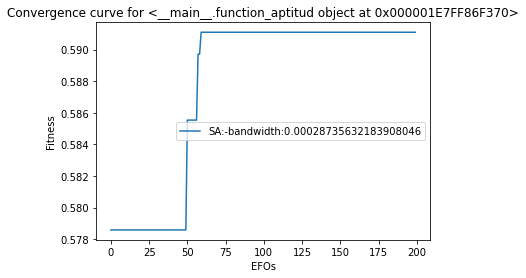

In [23]:
# d numero de atributos
import time
d = 174
f = function_aptitud()
max_efos = 200
bw = 1/d/20
seed = 42
swaps = 5
sa = SA(max_efos=max_efos, bandwidth=bw, swaps=swaps)
print(sa)
start_timer = time.time()
curve = sa.evolve(seed=seed, d=d, f=f, df_norm=df_norm, df=dataset_ditancia, lista_modelos=list_final_models, limites_15=limites_15)
end_timer = time.time()
print("Elapsed time: ", end_timer - start_timer)
best = sa.best
print(best.fitness)
plot_convergence_curve(curve, f, sa)

In [102]:
len(best.cells)
vector_optimizacion = best.cells

In [103]:
vector_optimizacion

array([0.00168651, 0.01179785, 0.0006465 , 0.00703735, 0.01149429,
       0.01208429, 0.00194272, 0.00453814, 0.01210129, 0.00282661,
       0.00269402, 0.01171164, 0.01207376, 0.01149222, 0.00571656,
       0.00233471, 0.00578747, 0.00141623, 0.00423953, 0.00620903,
       0.00238561, 0.01188055, 0.01254404, 0.00257771, 0.01219791,
       0.01197962, 0.00243587, 0.01165441, 0.01201991, 0.01241147,
       0.01198973, 0.00184192, 0.01223508, 0.01103399, 0.00633062,
       0.00484523, 0.00084883, 0.01187268, 0.00425385, 0.00582653,
       0.00172742, 0.01234055, 0.00289161, 0.01216871, 0.01219441,
       0.01185627, 0.00172413, 0.00271288, 0.01254837, 0.01191406,
       0.00574454, 0.01273933, 0.01227165, 0.00503218, 0.00170492,
       0.01216167, 0.00287005, 0.01183442, 0.00246524, 0.01184757,
       0.01187403, 0.00426254, 0.01204209, 0.01220539, 0.00283174,
       0.01111882, 0.0113413 , 0.00107454, 0.01189302, 0.01269005,
       0.01219024, 0.00232788, 0.00253695, 0.00117214, 0.01146

In [99]:
dataset_test

,ID_LOTE,DIAS_EN_EMERGER,DIAS_EN_EMERGER_A_FLORECER,DIAS_EN_FLORECER_A_COSECHAR,POBLACION_20DIAS_AJT,ALTURA_LOT,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,...,CAP_ENDURE_RASTA,MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_RAICES_VIVAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA
198,2044,3,46,84,55000,4,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
662,4168,6,48,74,60000,15,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
218,2097,5,53,65,75000,10,0,0,0,0,...,0,0,0,0,0,1,1,0,1,1
516,3066,4,47,83,60000,9,1,0,0,0,...,0,1,0,0,0,1,0,0,1,0
37,672,7,39,113,64000,14,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,2636,4,56,84,60000,10,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
713,4226,6,49,55,60000,17,0,0,0,0,...,0,0,0,0,0,1,1,0,1,0
761,4296,6,48,83,60000,17,0,0,0,0,...,0,0,0,0,0,1,1,0,1,1
497,3046,4,47,85,55000,13,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0


### Proceso conjunto de datos de validación

In [174]:
def predictionTest(dataset_test_norm, df_norm, vector_pesos_optmizacion, final_datset_join, list_final_models,dataset_validation, y_true):
    df_groups_finally = df_norm.copy()
    print("Longitud dataset norm: ",dataset_test_norm.shape[0])
    print("Vista minable : ",df_groups_finally.shape[0])

    MAE = 0
    PSI15 =0 
    y_pred_test = []
    for z in range(int(dataset_test_norm.shape[0])):
        minDep = sys.float_info.max
        posMinDep = 0
        for k in range(int(df_groups_finally.shape[0])):
            ri = vector_pesos_optmizacion * np.power((dataset_test_norm[z]- df_groups_finally[k]),2) 
            dE = np.sqrt(np.sum(ri))
            if dE < minDep:
                posMinDep = k
                minDep=dE
        
  
        # Grupo seleccionado
        grupoSelected = int(final_datset_join.values[posMinDep][-1])
        print(f" Para el registro {z} el grupo seleccionado es: {grupoSelected}")
        #model_final, r2_final, yhat_final = LinearRegession(definitive_groups[i],0.1, 0.97).CalcularModeloLR() 
        psi_predicho = list_final_models[grupoSelected].predict(dataset_validation.values[z].reshape(1,-1))
        #print(psi_predicho)
        if psi_predicho[0] >= (y_true[z][0]) *0.85 and psi_predicho[0] <= (y_true[z][0])*1.15:
            PSI15 = PSI15 + 1

        MAE = MAE + np.power((y_true[z][0] - psi_predicho),2)
        y_pred_test.append(psi_predicho[0])

    return [y_pred_test , MAE, PSI15]


In [175]:
#  Proceso Para el conjunto de Testeo.
#===================================================================================================
# 1. Normalización conjunto de test con los encoders
dataset_validation = dataset_test.copy()
dataset_validation = dataset_validation.drop(["ID_LOTE", "RDT_AJUSTADO"], axis=1)
dataset_test_norm = NormalizeViewMinable(dataset_validation.values[:,:], valMin, dataRange)
print(dataset_test_norm.shape)



(80, 174)


In [150]:
df_norm

array([[0.4       , 0.27118644, 0.43283582, ..., 0.        , 0.        ,
        0.        ],
       [0.33333333, 0.3559322 , 0.47761194, ..., 0.        , 0.        ,
        1.        ],
       [0.4       , 0.38983051, 0.55223881, ..., 0.        , 1.        ,
        0.        ],
       ...,
       [0.33333333, 0.3220339 , 0.53731343, ..., 0.        , 1.        ,
        1.        ],
       [0.33333333, 0.37288136, 0.49253731, ..., 0.        , 1.        ,
        0.        ],
       [0.4       , 0.22033898, 0.55223881, ..., 0.        , 1.        ,
        1.        ]])

In [189]:
# 2. y hat Modelo CLR
y_true = dataset_test.RDT_AJUSTADO.values.reshape(-1,1)
yhat_test, MAE_, P_15 = predictionTest(dataset_test_norm, df_norm,w, dataset_ditancia, list_final_models,dataset_validation, y_true)
print("MAE ", MAE_/80)
print("PSI 15: ", P_15)




# Crear un DataFrame con ambas columnas
df_resultados = pd.DataFrame({
    'y_true': y_true.flatten(),     # aplana por si tiene forma (n,1)
    'yhat_test': yhat_test
})

# Guardar el DataFrame en un archivo CSV
df_resultados.to_csv('resultados_prediccion.csv', index=False)

Longitud dataset norm:  80
Vista minable :  719
 Para el registro 0 el grupo seleccionado es: 1
 Para el registro 1 el grupo seleccionado es: 1
 Para el registro 2 el grupo seleccionado es: 0
 Para el registro 3 el grupo seleccionado es: 1
 Para el registro 4 el grupo seleccionado es: 1
 Para el registro 5 el grupo seleccionado es: 2
 Para el registro 6 el grupo seleccionado es: 2
 Para el registro 7 el grupo seleccionado es: 2
 Para el registro 8 el grupo seleccionado es: 0
 Para el registro 9 el grupo seleccionado es: 1
 Para el registro 10 el grupo seleccionado es: 0
 Para el registro 11 el grupo seleccionado es: 0
 Para el registro 12 el grupo seleccionado es: 2
 Para el registro 13 el grupo seleccionado es: 1
 Para el registro 14 el grupo seleccionado es: 2
 Para el registro 15 el grupo seleccionado es: 1
 Para el registro 16 el grupo seleccionado es: 1
 Para el registro 17 el grupo seleccionado es: 0
 Para el registro 18 el grupo seleccionado es: 2
 Para el registro 19 el grupo s

In [172]:
yhat_test,

([3217.1313748752727,
  6713.5457940650085,
  3840.6666816621455,
  4799.093352331351,
  3242.3489219255716,
  5701.992125358673,
  3992.61516222472,
  6882.3192881088125,
  -1053.6228762836108,
  3561.0674216862717,
  5438.432621333937,
  5161.341549436434,
  5583.593749688853,
  4972.161149954842,
  4158.574268789653,
  3645.556613882749,
  6419.410604026569,
  2877.0281308687736,
  5398.5559588099695,
  5063.104157396225,
  2235.249081343951,
  5697.6364230333165,
  4956.362892050012,
  10614.801595175531,
  4140.140525339533,
  914.2007503344284,
  5402.014979232874,
  6512.757511070362,
  2617.418316481957,
  2900.1182919308176,
  5133.553153083534,
  5855.017339065267,
  4262.898913041185,
  5669.154133446993,
  3785.0256449692097,
  2209.4303623187943,
  4653.064329257781,
  1953.0328247017442,
  4683.9433712643695,
  6022.174150435876,
  3054.7146317947736,
  6728.543006940905,
  3977.0506806144404,
  4309.23906913644,
  3590.1888819847954,
  3024.6755413943247,
  6701.47820858

In [173]:
metrics = metricasModelosRegresion(y_true, yhat_test)
metrics

(-0.726227999649125,
   Métrica         Valor
 0     MSE  4.046982e+06
 1    RMSE  2.011711e+03
 2     MAE  1.242030e+03
 3      R² -7.262280e-01)